## What are the most demanded skills?

### Methodology:

#### 1. Clean-up skill column
#### 2. Calculate skill count based on job_title_short
#### 3. Calculate skill percentage
#### 4. Plot final findings

In [1]:
# Importing libraries

import ast
import pandas as pd 
import seaborn as sns 
from datasets import load_dataset
import matplotlib.pyplot as plt 

# Loading data 

dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

# Data cleanup

df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)

In [2]:
# European jobs filter

european_countries = [
    'Albania', 'Andorra', 'Austria', 'Belarus', 'Belgium', 
    'Bosnia and Herzegovina', 'Bulgaria', 'Croatia', 'Cyprus', 'Czechia', 'Czech Republic', 
    'Denmark', 'Estonia', 'Finland', 'France', 'Germany', 'Greece', 'Hungary', 
    'Iceland', 'Ireland', 'Italy', 'Kosovo', 'Latvia', 'Liechtenstein', 
    'Lithuania', 'Luxembourg', 'Malta', 'Moldova', 'Monaco', 'Montenegro', 'Netherlands', 
    'North Macedonia', 'Norway', 'Poland', 'Portugal', 'Romania', 'Russia', 'San Marino', 
    'Serbia', 'Slovakia', 'Slovenia', 'Spain', 'Sweden', 'Switzerland', 'Turkey', 
    'Ukraine', 'United Kingdom', 'UK', 'Vatican City'
]

# Condition to meet
df_europe = df[df['job_country'].isin(european_countries)]

In [3]:
df_skills = df_europe.explode('job_skills')

df_skills [['job_title', 'job_skills']]

,job_title,job_skills
2,"Data Engineer/Scientist/Analyst, Mid or Senior...",python
2,"Data Engineer/Scientist/Analyst, Mid or Senior...",sql
2,"Data Engineer/Scientist/Analyst, Mid or Senior...",c#
2,"Data Engineer/Scientist/Analyst, Mid or Senior...",azure
2,"Data Engineer/Scientist/Analyst, Mid or Senior...",airflow
...,...,...
785735,Senior Data Engineer,docker
785737,CRM Data Analyst,sas
785737,CRM Data Analyst,sas
785737,CRM Data Analyst,sql


In [7]:
df_skills_count = df_skills.groupby(['job_skills', 'job_title_short']).size()

df_skills_count = df_skills_count.reset_index(name='skill_count')

df_skills_count.sort_values(by='skill_count', ascending=False, inplace=True)

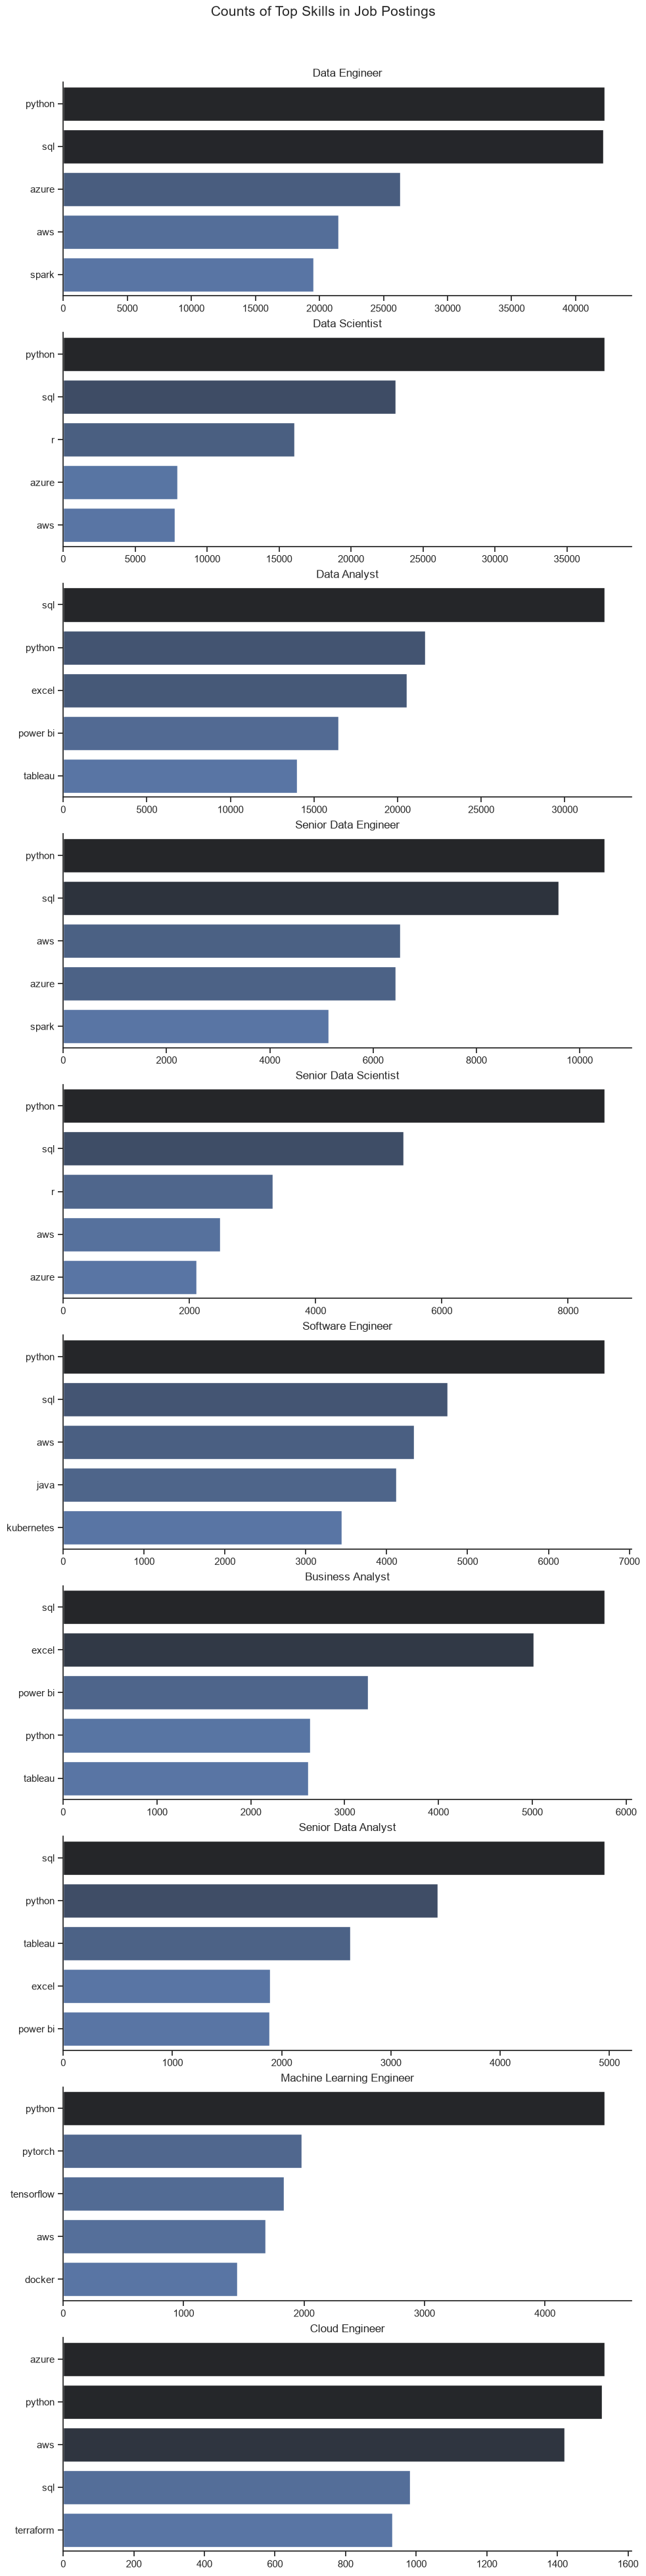

In [23]:
sns.set_theme(style='ticks')

job_titles = df_skills_count['job_title_short'].unique()

fig, ax = plt.subplots(len(job_titles), 1, figsize=(10, 4 * len(job_titles)))

for i, job_title in enumerate(job_titles):
    df_plot = df_skills_count[df_skills_count['job_title_short'] == job_title].head(5)
    
    sns.barplot(
        data=df_plot, 
        x='skill_count', 
        y='job_skills', 
        hue='skill_count', 
        palette='dark:b_r', 
        ax=ax[i],
        legend=False
    )
    
    ax[i].set_title(job_title)
    ax[i].set_ylabel('')
    ax[i].set_xlabel('')

sns.despine()
fig.suptitle('Counts of Top Skills in Job Postings', fontsize=15)
fig.tight_layout(h_pad=0.5, rect=[0, 0, 1, 0.97])
plt.show()

In [15]:
df_job_title_count = df_europe['job_title_short'].value_counts().reset_index(name='jobs_total')

In [20]:
df_skills_perc = pd.merge(df_skills_count, df_job_title_count, how='left', on='job_title_short')

df_skills_perc['skill_percent'] = 100 * df_skills_perc['skill_count'] / df_skills_perc['jobs_total']

df_skills_perc

,job_skills,job_title_short,skill_count,jobs_total,skill_percent
0,python,Data Engineer,42263,75201,56.200051
1,sql,Data Engineer,42164,75201,56.068403
2,python,Data Scientist,37630,58751,64.049974
3,sql,Data Analyst,32386,72551,44.638944
4,azure,Data Engineer,26302,75201,34.975599
...,...,...,...,...,...
2078,airtable,Senior Data Engineer,1,16374,0.006107
2079,wrike,Senior Data Scientist,1,12276,0.008146
2080,wrike,Senior Data Analyst,1,8497,0.011769
2081,airtable,Cloud Engineer,1,5492,0.018208


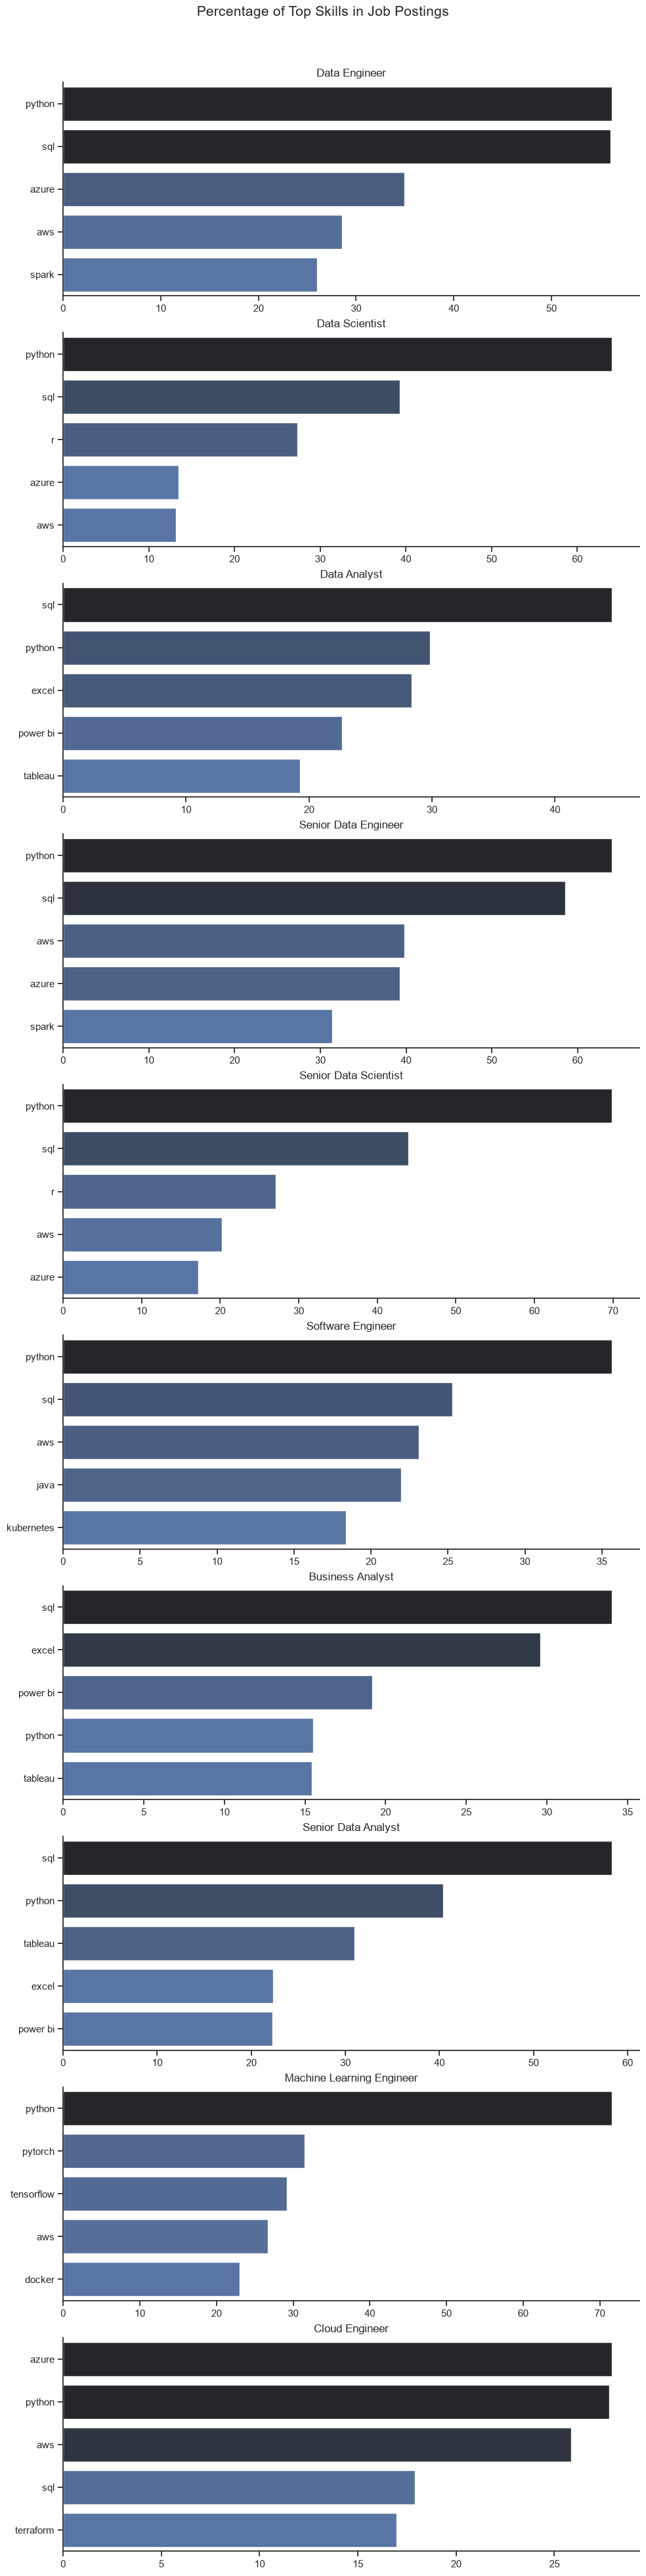

In [22]:
sns.set_theme(style='ticks')

job_titles = df_skills_perc['job_title_short'].unique()

fig, ax = plt.subplots(len(job_titles), 1, figsize=(10, 4 * len(job_titles)))

for i, job_title in enumerate(job_titles):
    df_plot = df_skills_perc[df_skills_perc['job_title_short'] == job_title].head(5)
    
    sns.barplot(
        data=df_plot, 
        x='skill_percent', 
        y='job_skills', 
        hue='skill_percent', 
        palette='dark:b_r', 
        ax=ax[i],
        legend=False
    )
    
    ax[i].set_title(job_title)
    ax[i].set_ylabel('')
    ax[i].set_xlabel('')

sns.despine()
fig.suptitle('Percentage of Top Skills in Job Postings', fontsize=15)
fig.tight_layout(h_pad=0.5, rect=[0, 0, 1, 0.97])
plt.show()